**Experiment 3: Visualization of Attention Weights and Transformer Architecture**

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel

In [ ]:
# Load a small transformer with attention outputs enabled
MODEL_NAME = "bert-base-uncased"   # small, well-known encoder transformer

print(f"[Step 1] Loading model & tokenizer: {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME, output_attentions=True)
model.eval()   # inference mode, no gradient updates needed

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"[Step 1] Model loaded on device: {device}")
print(f"[Step 1] Number of layers: {model.config.num_hidden_layers}, "
      f"Number of attention heads per layer: {model.config.num_attention_heads}")

[Step 1] Loading model & tokenizer: bert-base-uncased ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Step 1] Model loaded on device: cpu
[Step 1] Number of layers: 12, Number of attention heads per layer: 12


In [ ]:
# Tokenize a short sentence and print its tokens
default_sentence = "The cat sat on the mat because it was tired."
user_sentence = input(
    f"\nEnter a sentence to analyze (press Enter to use default:\n"
    f"'{default_sentence}'): \n> "
).strip()

sentence = user_sentence if user_sentence else default_sentence
print(f"\n[Step 2] Analyzing sentence: \"{sentence}\"")

inputs = tokenizer(sentence, return_tensors="pt").to(device)
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
print(f"[Step 2] Tokens ({len(tokens)}): {tokens}")


Enter a sentence to analyze (press Enter to use default:
'The cat sat on the mat because it was tired.'): 
> The cat sat on the mat because it was tired.

[Step 2] Analyzing sentence: "The cat sat on the mat because it was tired."
[Step 2] Tokens (13): ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', 'because', 'it', 'was', 'tired', '.', '[SEP]']


In [ ]:
# Run the model on the sentence
print("\n[Step 3] Running forward pass through the model...")
with torch.no_grad():
    outputs = model(**inputs)

# outputs.attentions -> tuple of length num_layers,
# each element shape: (batch, num_heads, seq_len, seq_len)
attentions = outputs.attentions
print(f"[Step 3] Got attention tensors for {len(attentions)} layers, "
      f"each of shape {tuple(attentions[0].shape)}")


[Step 3] Running forward pass through the model...
[Step 3] Got attention tensors for 12 layers, each of shape (1, 12, 13, 13)


In [ ]:
# Select one transformer layer and one attention head
# ---- USER INPUT: choose which layer/head to inspect ----
num_layers = model.config.num_hidden_layers
num_heads = model.config.num_attention_heads

try:
    layer_idx = int(input(
        f"\n[Step 4] Choose a layer index (0 to {num_layers - 1}), "
        f"Enter for default (last layer): "
    ) or num_layers - 1)
except ValueError:
    layer_idx = num_layers - 1

try:
    head_idx_1 = int(input(
        f"[Step 4] Choose first attention head index (0 to {num_heads - 1}), "
        f"Enter for default (head 0): "
    ) or 0)
except ValueError:
    head_idx_1 = 0

print(f"[Step 4] Selected layer {layer_idx}, head {head_idx_1}")


[Step 4] Choose a layer index (0 to 11), Enter for default (last layer): 0
[Step 4] Choose first attention head index (0 to 11), Enter for default (head 0): 5
[Step 4] Selected layer 0, head 5


In [ ]:
# Extract the attention matrix
# attentions[layer_idx] shape: (batch=1, num_heads, seq_len, seq_len)
attn_matrix_1 = attentions[layer_idx][0, head_idx_1].cpu().numpy()
print(f"[Step 5] Extracted attention matrix shape: {attn_matrix_1.shape}")

[Step 5] Extracted attention matrix shape: (13, 13)



[Step 6] Plotting heatmap for head 5 ...


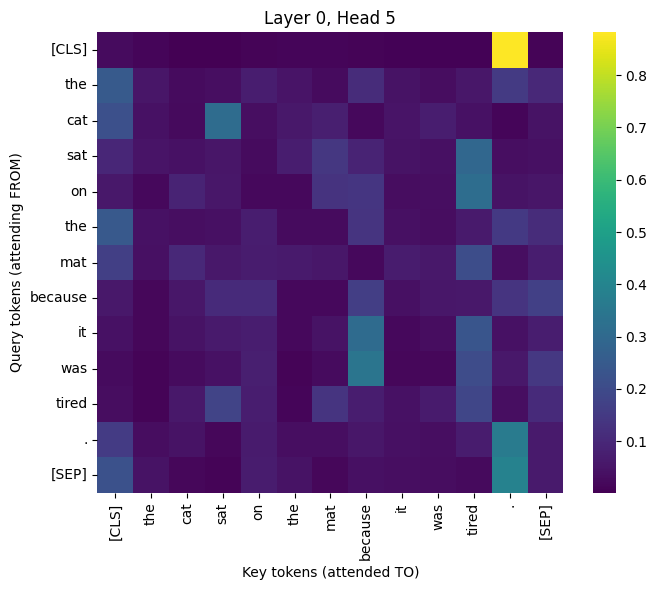

In [ ]:
# Plot it as a heatmap with tokens on both axes
def plot_attention_heatmap(matrix, tokens, layer_idx, head_idx, ax=None):
    """Plot a single attention head's matrix as a heatmap."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        matrix,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="viridis",
        cbar=True,
        ax=ax,
    )
    ax.set_title(f"Layer {layer_idx}, Head {head_idx}")
    ax.set_xlabel("Key tokens (attended TO)")
    ax.set_ylabel("Query tokens (attending FROM)")
    plt.setp(ax.get_xticklabels(), rotation=90)
    plt.setp(ax.get_yticklabels(), rotation=0)
    return ax

print("\n[Step 6] Plotting heatmap for head", head_idx_1, "...")
fig, ax = plt.subplots(figsize=(7, 6))
plot_attention_heatmap(attn_matrix_1, tokens, layer_idx, head_idx_1, ax=ax)
plt.tight_layout()
plt.savefig(f"attention_layer{layer_idx}_head{head_idx_1}.png", dpi=150)
plt.show()


[Step 7] Choose a second attention head index (0 to 11) to compare, Enter for default (head 11): 6
[Step 7] Plotting heatmap for head 6 for comparison ...


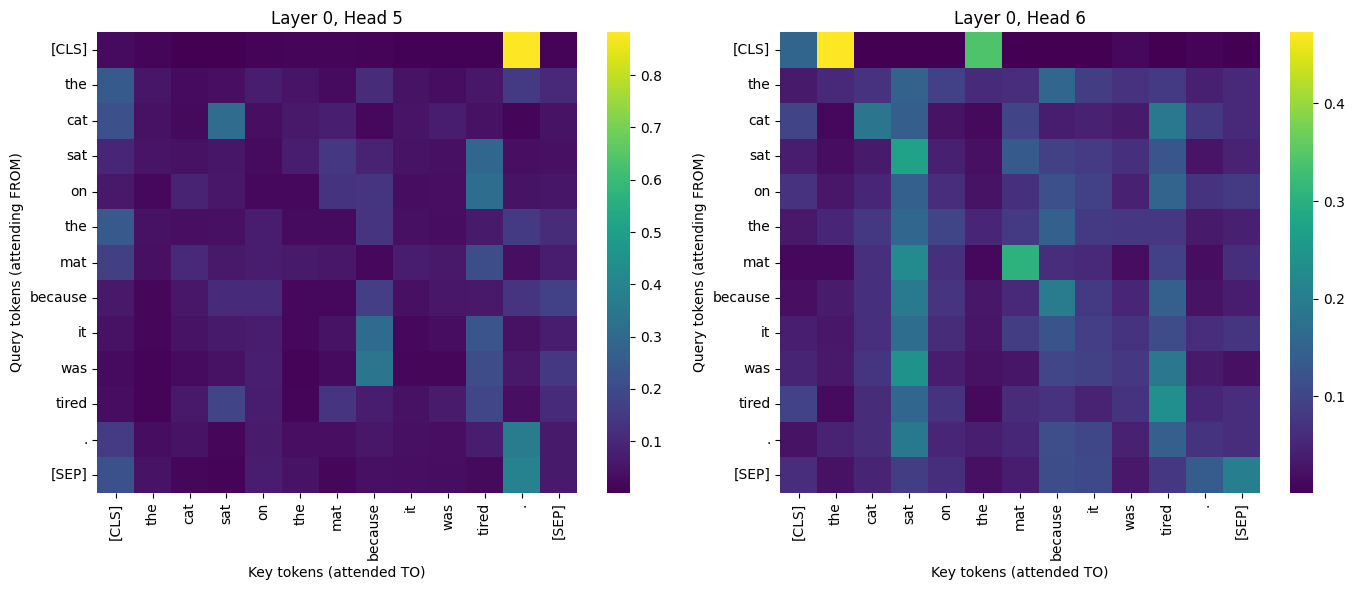

In [ ]:
# Repeat for another head and compare patterns
try:
    head_idx_2 = int(input(
        f"\n[Step 7] Choose a second attention head index (0 to {num_heads - 1}) "
        f"to compare, Enter for default (head {num_heads - 1}): "
    ) or num_heads - 1)
except ValueError:
    head_idx_2 = num_heads - 1

attn_matrix_2 = attentions[layer_idx][0, head_idx_2].cpu().numpy()
print(f"[Step 7] Plotting heatmap for head {head_idx_2} for comparison ...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_attention_heatmap(attn_matrix_1, tokens, layer_idx, head_idx_1, ax=axes[0])
plot_attention_heatmap(attn_matrix_2, tokens, layer_idx, head_idx_2, ax=axes[1])
plt.tight_layout()
plt.savefig(f"attention_compare_layer{layer_idx}_heads_{head_idx_1}_{head_idx_2}.png", dpi=150)
plt.show()

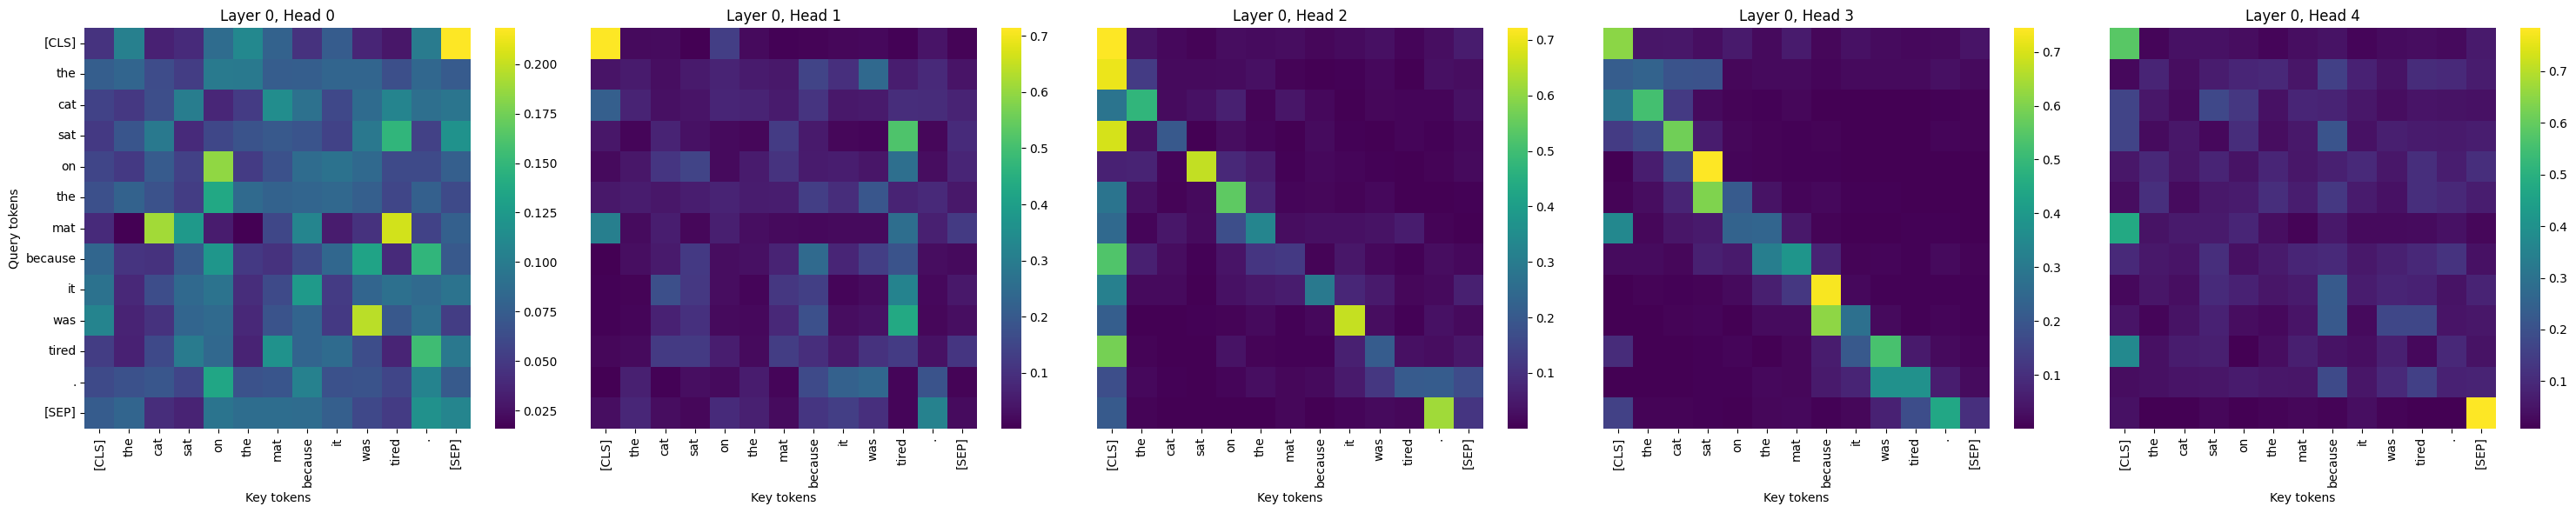

In [ ]:
# STEP 6-7 (MODIFIED): Plot 5 attention heads of the SAME layer, side by side
# for 5 heads instead of just 2.

num_heads_to_show = 5
heads_to_plot = list(range(num_heads_to_show))   # heads 0,1,2,3,4
# or pick specific ones, e.g. heads_to_plot = [0, 2, 4, 6, 11]

fig, axes = plt.subplots(1, num_heads_to_show, figsize=(6 * num_heads_to_show, 6))

for i, head_idx in enumerate(heads_to_plot):
    attn_matrix = attentions[layer_idx][0, head_idx].cpu().numpy()
    sns.heatmap(
        attn_matrix,
        xticklabels=tokens,
        yticklabels=tokens if i == 0 else False,  # only show y-labels on first plot
        cmap="viridis",
        cbar=True,
        ax=axes[i],
    )
    axes[i].set_title(f"Layer {layer_idx}, Head {head_idx}")
    axes[i].set_xlabel("Key tokens")
    if i == 0:
        axes[i].set_ylabel("Query tokens")
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig(f"attention_layer{layer_idx}_5heads.png", dpi=150)
plt.show()

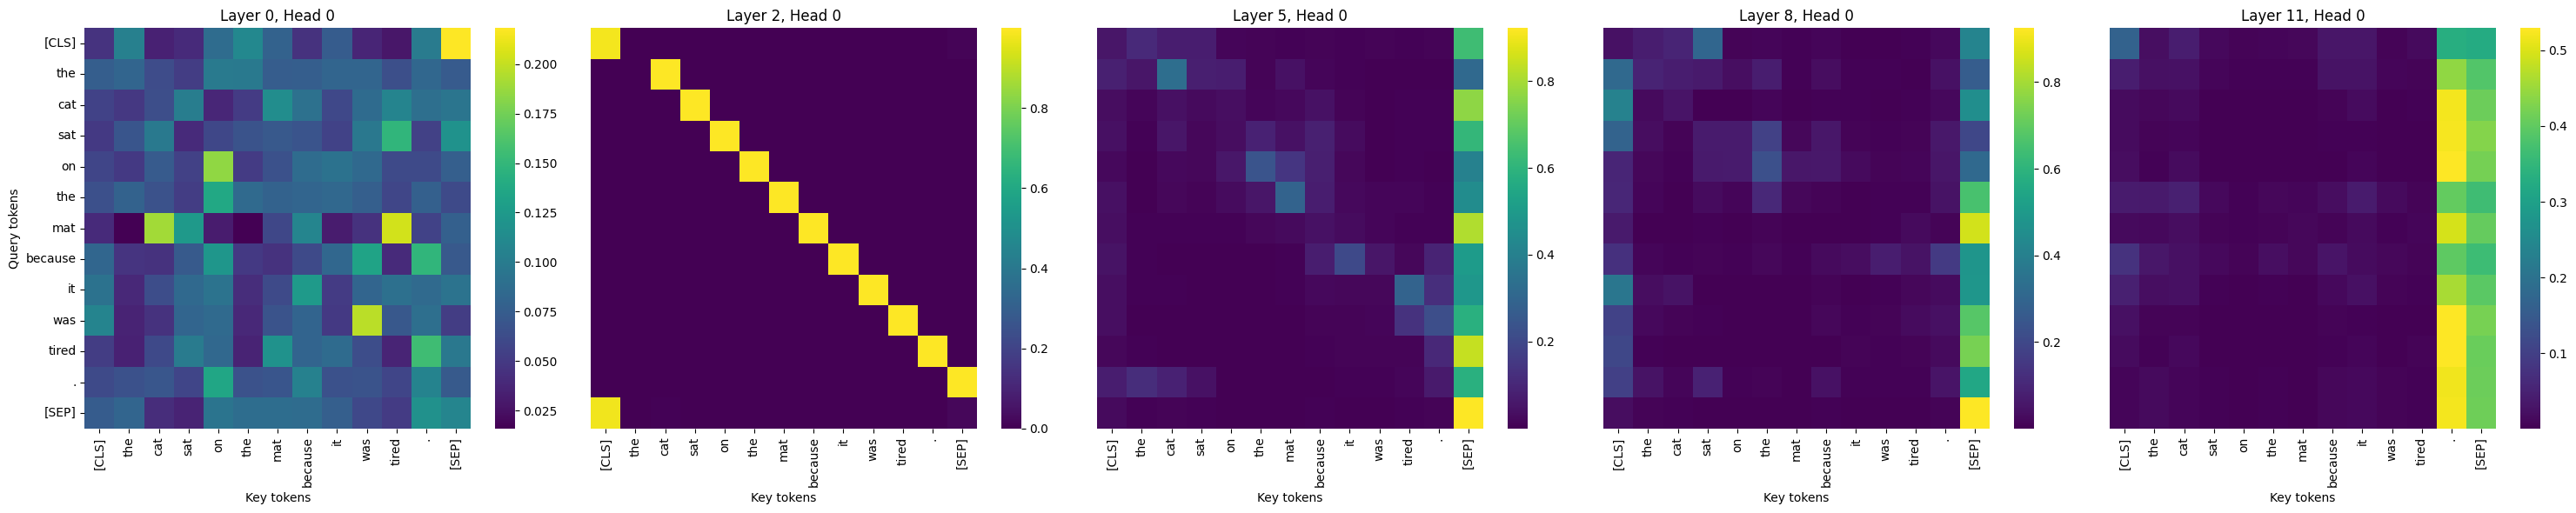

In [ ]:
# Plot the SAME head across 5 different layers
# layers (e.g. layer 0 -> layer 11) rather than across heads.

layers_to_plot = [0, 2, 5, 8, 11]   # 5 layers spread across the model
head_idx_fixed = 0                   # keep head fixed, vary layer instead

fig, axes = plt.subplots(1, len(layers_to_plot), figsize=(6 * len(layers_to_plot), 6))

for i, l_idx in enumerate(layers_to_plot):
    attn_matrix = attentions[l_idx][0, head_idx_fixed].cpu().numpy()
    sns.heatmap(
        attn_matrix,
        xticklabels=tokens,
        yticklabels=tokens if i == 0 else False,
        cmap="viridis",
        cbar=True,
        ax=axes[i],
    )
    axes[i].set_title(f"Layer {l_idx}, Head {head_idx_fixed}")
    axes[i].set_xlabel("Key tokens")
    if i == 0:
        axes[i].set_ylabel("Query tokens")
    axes[i].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig(f"attention_head{head_idx_fixed}_5layers.png", dpi=150)
plt.show()